# Multiclass glass classification

In this practical, we will look at multiclass classification - predicting one of many classes, rather than just one of two.

We'll be working with data from this 1987 forensic science paper: [Rule Induction in Forensic Science](http://www0.cs.ucl.ac.uk/staff/W.Langdon/ftp/papers/evett_1987_rifs.pdf)

In this paper, the authors classified fragments of glass into one of six classes, based on their chemical composition. This was motivated by the need to determine whether fragments of glass found on a suspect's clothing was of the same type of that at the crime scene.

The training data consists of 214 items. Each item has ten features and a type - the features are [Refractive Index](https://en.wikipedia.org/wiki/Refractive_index) and the weight percent in oxide form of 8 elements.

| Feature 	|    Description    	|
|:-------:	|:-----------------:	|
|    RI   	| Refractive Index  	|
|    Na   	| Sodium            	|
|    Mg   	| Magnesium          	|
|    Al   	| Aluminum          	|
|    Si   	| Silicon           	|
|    K    	| Potassium          	|
|    Ca   	| Calcium           	|
|    Ba   	| Barium            	|
|    Fe   	| Iron              	|

There are six types of glass: containers, tablewear, headlamps, vehicle, [float-processed](https://en.wikipedia.org/wiki/Float_glass) and non-float-processed building glass.


# Data exploration

First, let's look at the data. Below, after loading it in, look at the class balance with the `.value_counts()` applied to the relevant column. What do you observe?

In [1]:
import pandas as pd

data = pd.read_csv('data/glass.csv')

# Your code below
data.head()


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,building_fp
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,building_fp
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,building_fp
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,building_fp
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,building_fp


In [2]:
data.value_counts('Type')

Type
building_non_fp    76
building_fp        70
headlamps          29
vehicle            17
containers         13
tableware           9
Name: count, dtype: int64

For each class, what is the the average value and standard deviation per variable? What do you observe?

Which features do you think will be most useful for predicting which classes?

Will you need to do any data pre-processing?

(Hint: use `.groupby()` on a dataframe and then apply `.agg()`. This can take a list of arguments you want aggregate data for, such as `mean` and `std`.)

In [3]:
# Your code below
data.groupby('Type').agg(['mean', 'std'])


RI                   Na                  Mg            \
                     mean       std       mean       std      mean       std   
Type                                                                           
building_fp      1.518718  0.002268  13.242286  0.499301  3.552429  0.247043   
building_non_fp  1.518619  0.003802  13.111711  0.664159  3.002105  1.215661   
containers       1.518928  0.003345  12.827692  0.777037  0.773846  0.999146   
headlamps        1.517116  0.002545  14.442069  0.686359  0.538276  1.117683   
tableware        1.517456  0.003116  14.646667  1.084020  1.305556  1.097134   
vehicle          1.517964  0.001916  13.437059  0.506887  3.543529  0.162786   

                       Al                   Si                   K            \
                     mean       std       mean       std      mean       std   
Type                                                                           
building_fp      1.163857  0.273158  72.619143  0.569484  0.447429  0.214879   
building_non_fp  1.408158  0.318340  72.598026  0.724573  0.521053  0.213726   
containers       2.033846  0.693920  72.366154  1.282319  1.470000  2.138695   
headlamps        2.122759  0.442726  72.965862  0.940234  0.325172  0.668493   
tableware        1.366667  0.571861  73.206667  1.079467  0.000000  0.000000   
vehicle          1.201176  0.347489  72.404706  0.512276  0.406471  0.229890   

                        Ca                  Ba                  Fe            
                      mean       std      mean       std      mean       std  
Type                                                                          
building_fp       8.797286  0.574807  0.012714  0.083838  0.057000  0.089075  
building_non_fp   9.073684  1.921635  0.050263  0.362340  0.079737  0.106433  
containers       10.123846  2.183791  0.187692  0.608251  0.060769  0.155588  
headlamps         8.491379  0.973505  1.040000  0.665341  0.013448  0.029794  
tableware         9.356667  1.449948  0.000000  0.000000  0.000000  0.000000  
vehicle           8.782941  0.380111  0.008824  0.036380  0.057059  0.107864

# Standardisation

As the features do not have the same scale, let's fix that so that they have mean 0 and stdev 1 and it will be easier for us to examine and also easier for models to learn from.

In [4]:
from sklearn.preprocessing import StandardScaler

# Rescale the features to have std 1 and mean 0
scaler = StandardScaler()
columns = ['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe']
data[columns] = scaler.fit_transform(data[columns])

The cell below will show the distribution of the feature values for each class.

Which classes, if any, have a distinctive distribution?

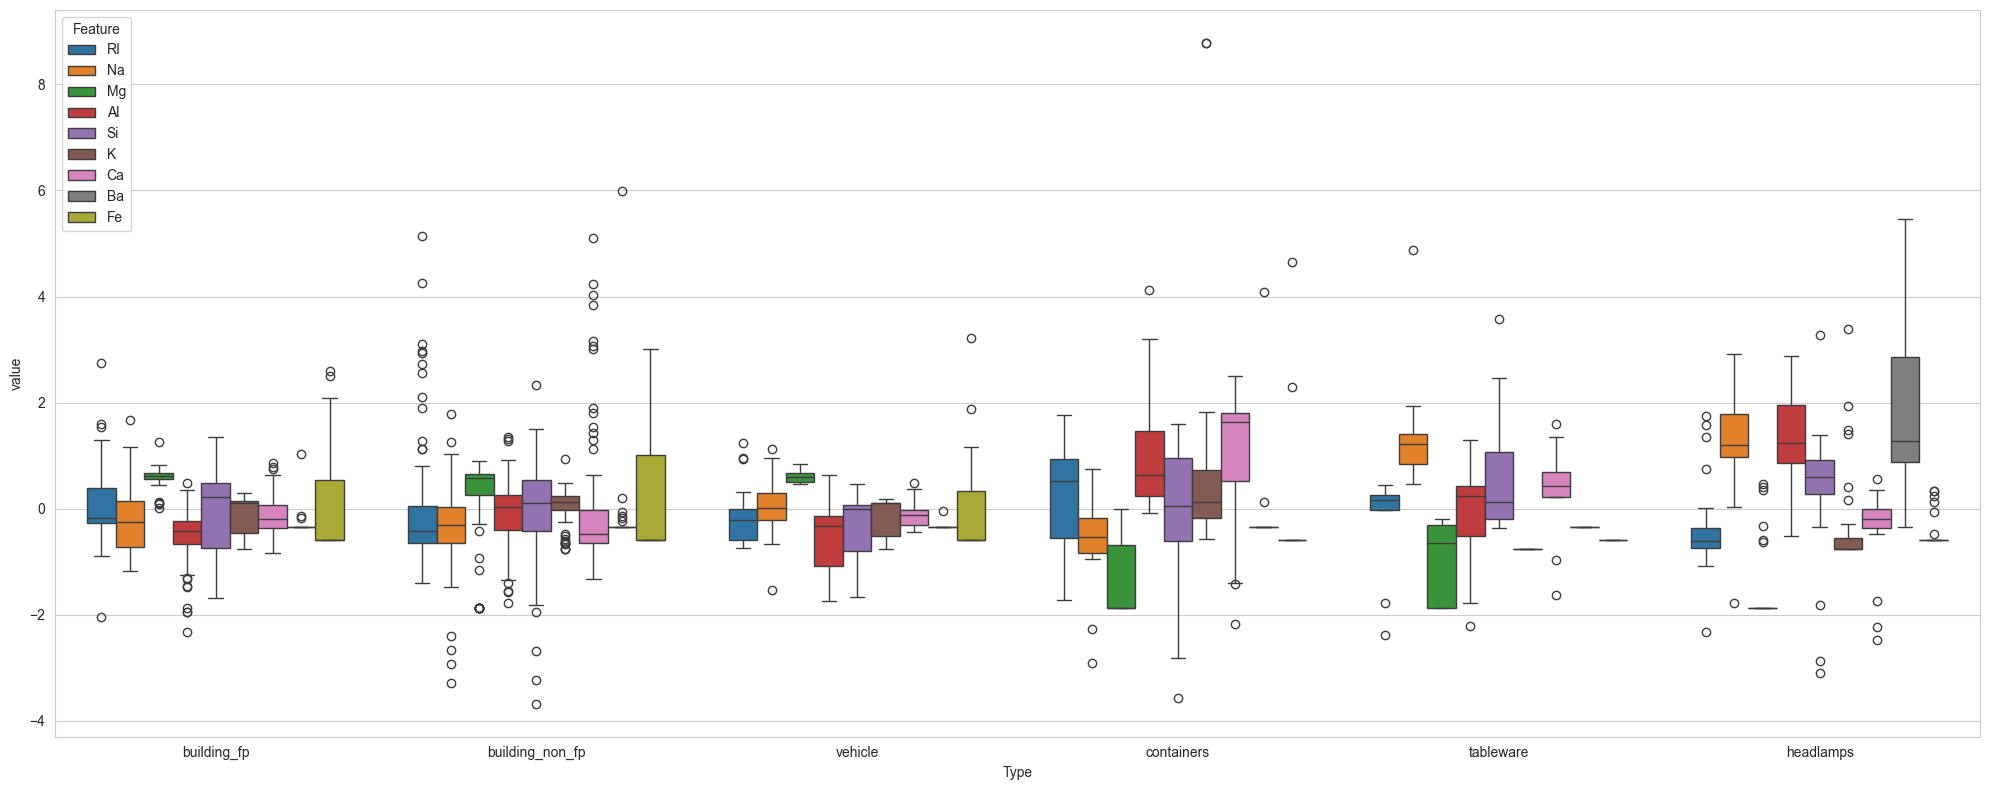

In [5]:
import seaborn as sns

# Grid lines make it easier to compare along rows
sns.set_style('whitegrid') 

import matplotlib.pyplot as plt

# Set up the size of the plot
plt.figure(figsize=(20,8)) 

# Long-format data is easier to plot with seaborn
long_data = data.melt(id_vars=['Type'], var_name='Feature')

# Box plot
sns.boxplot(data=long_data, x='Type', hue='Feature', y='value')

# Tidy up layout
plt.tight_layout()


#Your thoughts below


# Setting up data

The normalised data is still in a DataFrame. Split it into two parts - the features `X` and the class labels `y`

In [6]:
#Your code below
X=data.drop('Type', axis=1)
y=data['Type']

Now, create train/test sets: `X_train`, `X_test`, `y_train` and `y_test`.

As we have only around 200 data points, use 20% of data for testing rather than the default 25%. Use `random_state=5` to get the same results each time.

(You can use the `test_size` parameter for this.)

In [7]:
from sklearn.model_selection import train_test_split

#Your code below
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)

# Training and evaluating models

The original paper from 1987 used [BEAGLE](https://www.emerald.com/insight/content/doi/10.1108/eb005587/full/html) to classify their data - a rule-based algorithm from 1981 for classifying data, inspired by Darwinian evolution. Rules like "were evaluated for their "goodness" and only the best rules kept.

Let's compare some models which are, by default, multiclass to some models which need to use a multiclass strategy such as 'One-V-One' or 'One-V-Rest'.

After they have been imported below:

* instantiate one of each model. (Use the default hyperparameters, except for the SVM - set `max_iter=2000` otherwise the model will not converge. And for LR/SVM set `random_state=5`)
* use the `.fit()` method of each to train the model using the training data (`X_train`, `y_train`)
* then use each model's `.score()` method on the training data (to see if they overfitted)
* and then again on the test data (to see if they generalised)

In [19]:
# Multiclass by default
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Binary only
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression

#Your code below
dt=DecisionTreeClassifier()
knn=KNeighborsClassifier()
svc=LinearSVC(max_iter=2000, random_state=5, dual="auto")
lr=LogisticRegression(random_state=5)

dt.fit(X_train, y_train)
knn.fit(X_train, y_train)
svc.fit(X_train, y_train)
lr.fit(X_train, y_train)


# print("dt train : " + str(dt.score(X_train, y_train) ))
# print("knn train : " + str(knn.score(X_train, y_train)))
# print("svc train : " + str(svc.score(X_train, y_train)))
# print("lr train : " + str(lr.score(X_train, y_train)))

# print("dt test : " + str(dt.score(X_test, y_test)))  
# print("knn test : " + str(knn.score(X_test, y_test)))
# print("svc test : " + str(svc.score(X_test, y_test)))
# print("lr test : " + str(lr.score(X_test, y_test)))


# Score them on seen/unseen data
for model in [dt, knn, svc, lr]:
    print(f"Accuracy for {model} (seen data):\t {model.score(X_train, y_train):.3f}")
    print(f"Accuracy for {model} (unseen data):\t {model.score(X_test, y_test):.3f}")
    print('='*38)



Accuracy for DecisionTreeClassifier() (seen data):	 1.000
Accuracy for DecisionTreeClassifier() (unseen data):	 0.698
Accuracy for KNeighborsClassifier() (seen data):	 0.784
Accuracy for KNeighborsClassifier() (unseen data):	 0.605
Accuracy for LinearSVC(max_iter=2000, random_state=5) (seen data):	 0.673
Accuracy for LinearSVC(max_iter=2000, random_state=5) (unseen data):	 0.721
Accuracy for LogisticRegression(random_state=5) (seen data):	 0.678
Accuracy for LogisticRegression(random_state=5) (unseen data):	 0.698


The DT overfits, as usual, but generalises well.

The other models perform around the same on unseen data, though KNN (the simplest model) is the worst overall.

The SVM actually does slightly better on the unseen data! But this is likely due to randomisation/initialisation issues.

# Looking at per-class performance

The accuracy score gives one impression of how well a model does, but the per-class peformance gives a much more nuanced picture.

Use the `classification_report` function to see how well each model performed on each of the six classes.

To do this, use each trained models `.predict()` function on the `X_test` data. Then pass these predictions and the true labels `y_test` to `classification_report`.

Store the predictions of each model as `dt_pred` `kn_pred` `svm_pred` `lm_pred`

What do you notice?

In [ ]:
from sklearn.metrics import classification_report

#Your code and thoughts below
# print(classification_report(y_test, knn.predict(X_test)))
# print(classification_report(y_test, dt.predict(X_test)))
# print(classification_report(y_test, svc.predict(X_test)))
# print(classification_report(y_test, lr.predict(X_test)))


dt_pred = dt.predict(X_test)
print('\nReport for: DT')
print(classification_report(y_test, dt_pred, zero_division=0))
print('='*56)


kn_pred = knn.predict(X_test)
print('\nReport for: KNN')
print(classification_report(y_test, kn_pred, zero_division=0))
print('='*56)


svm_pred = svc.predict(X_test)
print('\nReport for: SVM')
print(classification_report(y_test, svm_pred, zero_division=0))
print('='*56)


lr_pred = lr.predict(X_test)
print('\nReport for: LR')
print(classification_report(y_test, lr_pred, zero_division=0))
print('='*56)


                 precision    recall  f1-score   support

    building_fp       0.55      0.75      0.63        16
building_non_fp       0.62      0.53      0.57        15
     containers       0.50      1.00      0.67         1
      headlamps       0.83      0.71      0.77         7
      tableware       0.00      0.00      0.00         2
        vehicle       0.00      0.00      0.00         2

       accuracy                           0.60        43
      macro avg       0.42      0.50      0.44        43
   weighted avg       0.56      0.60      0.58        43

                 precision    recall  f1-score   support

    building_fp       0.69      0.69      0.69        16
building_non_fp       0.85      0.73      0.79        15
     containers       1.00      1.00      1.00         1
      headlamps       0.75      0.86      0.80         7
      tableware       0.00      0.00      0.00         2
        vehicle       0.20      0.50      0.29         2

       accuracy           

/Users/SubasRW1/masters_project/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/SubasRW1/masters_project/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/SubasRW1/masters_project/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

# Looking at per-class performance

Another way to look at per-class performance is through a confusion matrix.

This shows which items got classified as what and allows you to see patterns, such as whether one class is always predicted as another.

The `confusion_matrix` function takes two lists: the true labels and the predicted ones.

It returns a matrix where rows are the true labels, columns are the predicted.

A cell at $(i,j)$ denotes the number of items of true class $i$ that were labelled with $j$.

Ideally you want all cells to have a value of 0 except on the diagonal.

The order of the rows (top to bottom) and columns (left to right) will be the same and will be in alphabetical order by default.

In [23]:
from sklearn.metrics import confusion_matrix

for predictions, model in zip([dt_pred, kn_pred, svm_pred, lr_pred], ['DT', 'KNN', 'SVM', 'LR']):
    print(f'Confusion matrix for {model}:')
    print(confusion_matrix(predictions, y_test))
    print()

Confusion matrix for DT:
[[11  3  0  0  1  1]
 [ 1 11  0  1  0  0]
 [ 0  0  1  0  0  0]
 [ 1  0  0  6  1  0]
 [ 0  0  0  0  0  0]
 [ 3  1  0  0  0  1]]

Confusion matrix for KNN:
[[12  6  0  1  1  2]
 [ 4  8  0  1  0  0]
 [ 0  1  1  0  0  0]
 [ 0  0  0  5  1  0]
 [ 0  0  0  0  0  0]
 [ 0  0  0  0  0  0]]

Confusion matrix for SVM:
[[10  2  0  0  0  1]
 [ 6 12  0  1  0  1]
 [ 0  1  1  0  0  0]
 [ 0  0  0  6  0  0]
 [ 0  0  0  0  2  0]
 [ 0  0  0  0  0  0]]

Confusion matrix for LR:
[[ 9  2  0  0  0  1]
 [ 7 13  0  1  1  1]
 [ 0  0  1  0  0  0]
 [ 0  0  0  6  0  0]
 [ 0  0  0  0  1  0]
 [ 0  0  0  0  0  0]]



# Looking at per-class performance

It's easier to understand the confusion matrix when plotted as a heatmap. `seaborn` has a useful function for this.

Run the cell below. What do you observe?

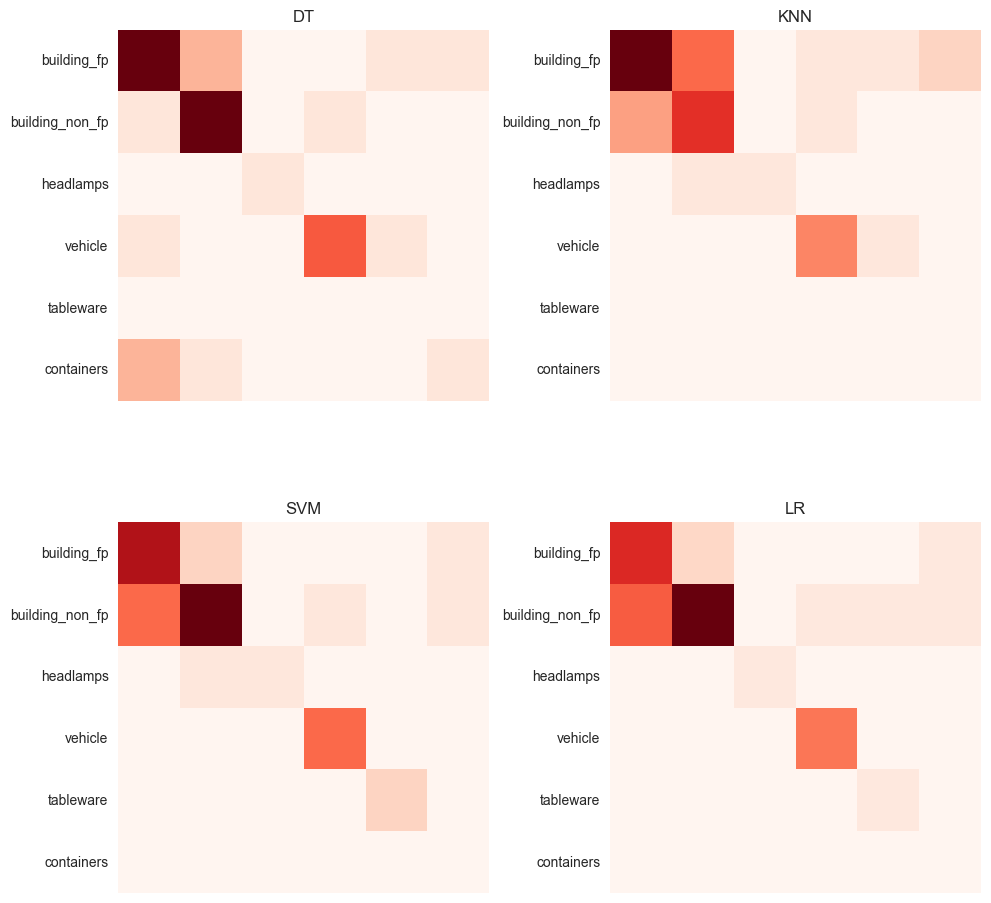

In [24]:
f, axs = plt.subplots(2,2, figsize=(10,10))

axs = axs.flatten()
labels = list(y_test.unique())

for preds, model, ax in zip([dt_pred, kn_pred, svm_pred, lr_pred], ['DT', 'KNN', 'SVM', 'LR'], axs):
    matrix = confusion_matrix(preds, y_test)
    sns.heatmap(matrix, square=True, annot=False, cmap='Reds', ax=ax, cbar=False)
    ax.set(title=model)
    ax.set(title=model, xticklabels='', yticklabels=labels)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()

#Your thoughts below


# OVR vs OVO

The sklearn models use OVR for their multiclass strategy. Would using OVO help?

Using the `OneVsOneClassifier` class from `sklearn.multiclass`, fit and train and evaluate it just like you would any other sklearn model.

How does it compare to the OVR strategy when you compare them by `classification_report`?


In [26]:
from sklearn.multiclass import OneVsOneClassifier

ovo = OneVsOneClassifier(estimator=LinearSVC(max_iter=2000, dual="auto"))

#Your code and thoughts below
ovo.fit(X_train, y_train)
ovo_pred = ovo.predict(X_test)
# print(classification_report(y_test, ovo_pred, zero_division=0))

print('OVO performance:')
print(classification_report(y_test, ovo_pred, zero_division=0))

print('='*56)

print('OVR performance:')
print(classification_report(y_test, svm_pred, zero_division=0))

OVO performance:
                 precision    recall  f1-score   support

    building_fp       0.71      0.62      0.67        16
building_non_fp       0.63      0.80      0.71        15
     containers       1.00      1.00      1.00         1
      headlamps       1.00      0.86      0.92         7
      tableware       0.50      0.50      0.50         2
        vehicle       0.00      0.00      0.00         2

       accuracy                           0.70        43
      macro avg       0.64      0.63      0.63        43
   weighted avg       0.70      0.70      0.69        43

OVR performance:
                 precision    recall  f1-score   support

    building_fp       0.77      0.62      0.69        16
building_non_fp       0.60      0.80      0.69        15
     containers       0.50      1.00      0.67         1
      headlamps       1.00      0.86      0.92         7
      tableware       1.00      1.00      1.00         2
        vehicle       0.00      0.00      0.00    

# Conclusion

Working with multiclass data doesn't generally require the use of a specific model - the binary classifiers can be adapted and still perform very well.

For small datasets it may still be worth evaluating different strategies. As we saw here, it helped a little. But you would likely get more of an improvement from better finetuning of model hyperparameters through grid search and cross-validation. Ideally, you would get more data!